In [47]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
print(df.info())
print("--"*50)
print(df.describe())
print("--"*50)
print(df['Outcome'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
----------------------------------------------------------------------------------------------------
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.0000

In [ ]:
X_raw = df.drop('Outcome', axis=1).values.astype(np.float32)  # all values in float. Standard for PyTorch
y_raw = df['Outcome'].values.astype(np.int64)   # 0 or 1. Required for classification loss

print(f"Features shape: {X_raw.shape}")
print(f"Target shape: {y_raw.shape}")

Features shape: (768, 8)
Target shape: (768,)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, train_size=0.7, random_state=42, stratify=y_raw)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 537
Test set size: 231


In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean/std from training
X_test_scaled = scaler.transform(X_test)         # uses same transformation

In [53]:
X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_train_tensor = torch.from_numpy(y_train).long()   # long = int64
y_test_tensor = torch.from_numpy(y_test).long()

**float64** -> doubletensors


*  Takes up twice the memory
*  Acccuracy = 15 to 17 digits ( after the decimal point )
---
**float32** -> singletensors
*   Takes up half the memory ( as compared to doubletensors )
*   Acccuracy = 7 digits ( after the decimal point )


     

In [54]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches in train_loader: {len(train_loader)}")
print(f"Batches in train_loader: {len(test_loader)}")

Batches in train_loader: 17
Batches in train_loader: 8


In [ ]:
num_batches_test = len(test_loader)
batch_size = test_loader.batch_size
num_samples_test = num_batches_test * batch_size
print(f"Number of batches in test_loader: {num_batches_test}")
print(f"Number of batch size in test_loader: {batch_size}")
print(f"Number of samples in test_loader: {num_samples_test}")

Number of batches in test_loader: 8
Number of batch size in test_loader: 32
Number of samples in test_loader: 256


In [ ]:
class DiabetesClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)   # output 1 logit for binary

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)                # raw logits (no activation)
        return x

model = DiabetesClassifier()
print(model)

DiabetesClassifier(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Adam -> Adaptive Moment Estimation

Different problems (different "factories") need different management styles:


*   **SGD** is like a simple, reliable manager – good when you have a clean, well‑behaved factory.

*   **Adam** is a versatile, adaptive manager – great for most modern factories.

*   **RMSprop** is good for factories where the noise changes over time.

*  **AdamW** is Adam with a better regularization trick.

In practice, Adam is a great starting point. If you want to squeeze out a bit more performance, you might try AdamW or SGD with momentum.

In [55]:
train_losses = []
train_accuracies = []

num_epochs = 200

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)                 # shape: (batch, 1)
        loss = criterion(outputs, y_batch.view(-1, 1).float())  # targets need shape (batch,1) and float
        loss.backward()
        optimizer.step()  # new_weight = old_weight - learning_rate * gradient

        running_loss += loss.item()  # dictionary

        # Accuracy: logit > 0 => class 1
        predicted = (outputs > 0).int()
        total += y_batch.size(0)
        correct += (predicted.view(-1) == y_batch).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")  # 3d -> in a field of width 3

print("Training finished!")

Epoch  20 | Loss: 0.0700 | Acc: 99.07%
Epoch  40 | Loss: 0.0547 | Acc: 99.26%
Epoch  60 | Loss: 0.0414 | Acc: 99.63%
Epoch  80 | Loss: 0.0327 | Acc: 100.00%
Epoch 100 | Loss: 0.0251 | Acc: 100.00%
Epoch 120 | Loss: 0.0186 | Acc: 100.00%
Epoch 140 | Loss: 0.0153 | Acc: 100.00%
Epoch 160 | Loss: 0.0118 | Acc: 100.00%
Epoch 180 | Loss: 0.0096 | Acc: 100.00%
Epoch 200 | Loss: 0.0074 | Acc: 100.00%
Training finished!


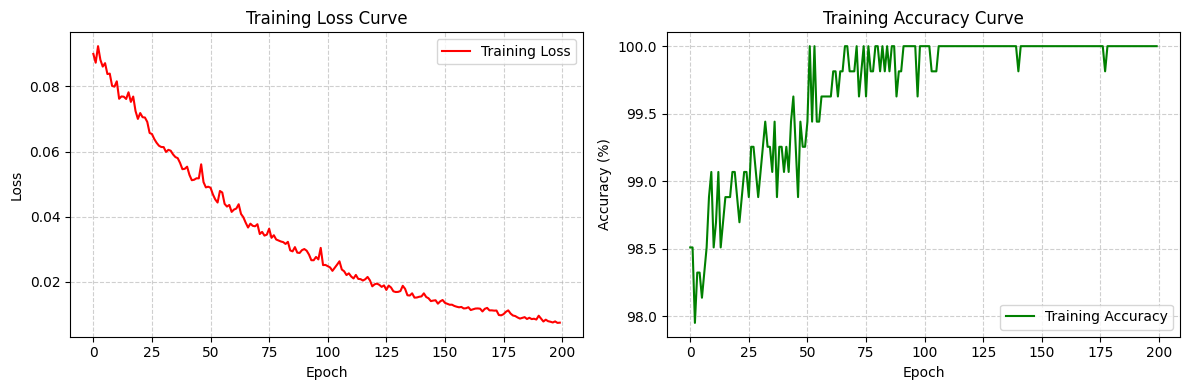

In [56]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        predicted = (outputs > 0).int()
        total += y_batch.size(0)
        correct += (predicted.view(-1) == y_batch).sum().item()

test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")


Test Accuracy: 72.29%
